# AI Workforce Forecasting for Warehouse Labor Optimization

## Springboard Data Analytics Final Capstone

This GitHub-ready notebook preserves the original forecasting logic while adding cleaner structure and professional explanations for review.

**Project objective:** use machine learning forecasting to simulate warehouse labor demand and support VET/VTO workforce decisions.

# Single step forecasting with machine learning

[Forecasting with Machine Learning - Course](https://www.trainindata.com/p/forecasting-with-machine-learning)

In this notebook, we will pick up the table of predictive features and a target from the first notebook and train a machine learning model to do forecasting.

We will do **single step** ahead forecasting.

# 1. Imports and Setup

This section loads the Python libraries required for forecasting, model evaluation, explainability, and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import root_mean_squared_error

# 2. Data Loading and Preprocessing

This project uses the Walmart retail forecasting dataset as a proxy for warehouse operational demand. The original data preparation logic is preserved to avoid changing the model behavior.

# Load data

We will use the electricity demand dataset found [here](https://github.com/tidyverts/tsibbledata/tree/master/data-raw/vic_elec/VIC2015).

**Citation:**

Godahewa, Rakshitha, Bergmeir, Christoph, Webb, Geoff, Hyndman, Rob, & Montero-Manso, Pablo. (2021). Australian Electricity Demand Dataset (Version 1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4659727

**Description of data:**

A description of the data can be found [here](https://rdrr.io/cran/tsibbledata/man/vic_elec.html). The data contains electricity demand in Victoria, Australia, at 30 minute intervals over a period of 12 years, from 2002 to early 2015. There is also the temperature in Melbourne at 30 minute intervals and public holiday dates.

In [2]:
!pip install sktime

In [3]:
!pip install shap

In [4]:
import os
print(os.getcwd())

D:\Work\Springboard\CAPSTONE-Final - Base-Github\TraininData\WORKTRAIN\WalmartBenchmark


In [5]:
import shap

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures


# 1. Load the data
train = pd.read_csv('data/raw/train.csv')
features = pd.read_csv('data/raw/features.csv')
stores = pd.read_csv('data/raw/stores.csv')

# 2. Merge dataframes combines  sales (target), external factors (future use), store info
# Why: So the model has all context (Store size, Temperature, etc.) in one row.
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on=['Store'], how='left')


In [7]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [8]:
#df['Date'] = pd.to_datetime(df['Date'])

# df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
#df = df.dropna(subset=['Date'])

#df_agg = df.reset_index(drop=True)   # remove fake 1970 index
df['Date'] = pd.to_datetime(df['Date'])  # use real dates

# 3. Set index
df = df.set_index('Date')


# 4. aggregated ALL stores into one time series earlier  and then created lag features on that aggregated data
#df_agg = df.groupby(df.index)['Weekly_Sales'].sum().to_frame()
df_agg = df.groupby(df.index).agg({
    'Weekly_Sales': 'sum',
    'IsHoliday': 'max',        # or 'mean'
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
})

df_agg = df_agg.reset_index()
df_agg = df_agg.sort_index()

df = df_agg.copy()

df = df[['Date', 'Weekly_Sales','IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

print(df.head())

        Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price         CPI  \
0 2010-02-05   49750740.50      False    33.277942    2.717869  167.398405   
1 2010-02-12   48336677.63       True    33.361810    2.696102  167.384138   
2 2010-02-19   48276993.78      False    37.038310    2.673666  167.338966   
3 2010-02-26   43968571.13      False    38.629563    2.685642  167.691019   
4 2010-03-05   46871470.30      False    42.373998    2.731816  167.727351   

   Unemployment  
0      8.576731  
1      8.567309  
2      8.576351  
3      8.561375  
4      8.572689  


In [9]:
print(df.tail())

          Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price         CPI  \
138 2012-09-28   43734899.40      False    68.151759    3.858245  175.919639   
139 2012-10-05   47566639.31      False    65.456811    3.848435  175.998254   
140 2012-10-12   46128514.25      False    57.687284    3.897425  176.123786   
141 2012-10-19   45122410.57      False    60.152756    3.878413  176.295499   
142 2012-10-26   45544116.29      False    60.530277    3.791086  176.182886   

     Unemployment  
138      7.225855  
139      6.942141  
140      6.952682  
141      6.948928  
142      6.943212  


# 3. Feature Engineering

Feature engineering captures historical demand behavior and operational demand dynamics. Lag features represent recent history, rolling features capture short-term trends, and proxy features simulate operational pressure.

## Lag features

We shift pass values of the time series forward. We discussed these 3 features in a previous notebook / video.

In [10]:
# df[f"lag_1"] = df["Weekly_Sales"].shift(periods=1)

# freq = "2"
# df[f"lag_{freq}"] = df["Weekly_Sales"].shift(periods=2)

# freq = "3"
# df[f"lag_{freq}"] = df["Weekly_Sales"].shift(periods=3)

# freq = "4"
# df[f"lag_{freq}"] = df["Weekly_Sales"].shift(periods=4)

# freq = "13"
# df[f"lag_{freq}"] = df["Weekly_Sales"].shift(periods=13)

# freq = "52"
# df[f"lag_{freq}"] = df["Weekly_Sales"].shift(periods=52)
# df.head()

## Window features

We aggregate values within windows in the past.  We discussed these windows in a previous notebook / video.

In [11]:
# # We'll use a 4 and 13 window size.

# result = (
#     df["Weekly_Sales"]
#     .rolling(window=4) # Pick window size.
#     .agg(["mean","std"]) # Pick statistics.
#     .shift(periods=1) # Lag by 1 week to avoid data leakage.
# )  

# result = result.add_prefix("rolling_4_")

# # add features to main dataframe

# df = df.merge(result, how="left", left_index=True, right_index=True)

In [12]:
# # We'll use a 4 and 13 window size.

# result = (
#     df["Weekly_Sales"]
#     .rolling(window=13) # Pick window size.
#     .agg(["mean", "std"]) # Pick statistics.
#     .shift(periods=1) # Lag by 1 week to avoid data leakage.
# )  

# result = result.add_prefix("rolling_13_")

# # add features to main dataframe

# df = df.merge(result, how="left", left_index=True, right_index=True)

# import pandas as pd
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 1000)

# #df.head(10)

In [13]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


#df.head(10)

## Datetime features

We'll create date and time related features from the time series. 

In [14]:
# df["month"] = df['Date'].dt.month
# df["day"] =df['Date'].dt.day
# df["year"] = df['Date'].dt.year

# df.head()

## Finalize tabularization

In [15]:
df.dropna(inplace=True)

y = df["Weekly_Sales"]
X = df.drop("Weekly_Sales", axis=1)

# Predictors
#X.head()

# 4. Recursive Forecasting with XGBoost

The primary forecasting model uses XGBoost inside a recursive forecasting workflow. This allows the model to generate future weekly forecasts while using previous forecast steps as part of the forecasting process.

## Recursive forecaster

We'll split the data into train and test.

We train the model on the train set and evaluate it on the test set.

In [16]:
from xgboost import XGBRegressor

model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
)

In [17]:
rolling_features = RollingFeatures(
    stats        = ['mean', 'mean', 'std', 'std'],
    window_sizes = [3, 24, 3, 24]
)

In [18]:
forecaster = ForecasterRecursive(
    estimator       = model,
    lags = [1, 2, 3, 4, 13],
    window_features = rolling_features
)

In [19]:
print(df.columns)

Index(['Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'], dtype='object')


In [20]:
y = df[['Weekly_Sales']]   # keep as DataFrame (consistent with your pipeline)

exog_features = ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
exog = df[exog_features]

## Operational Proxy Features

Sales velocity captures how quickly demand changes week to week. Backlog proxy approximates operational workload pressure or congestion. These are proxy variables because the dataset does not contain actual staffing or warehouse backlog data.

Proxies are:

engineered features that approximate real-world factors you don’t directly observe in the dataset

We don’t have:
warehouse congestion
staffing levels
shipping delays
backlog queues

the following  simulate them using data you do have (sales, temperature, etc.)
Sales Velocity represents Rate of change in demand:
    Sudden spikes → require rapid staffing (VET)
    Sudden drops → excess labor (VTO)
Example:
    Sales jump from 10K → 15K
    → velocity = +50%
    → signal: demand surge

Backlog Proxy represents Demand pressure relative to recent trend- Are we falling behind or catching up?
    If demand > recent average → system under stress
    If demand < average → slack capacity

Extreme Temperature represents Environmental stress on operations - External conditions making operations harder
    Extreme heat/cold:
        slows workers
        affects logistics
        increases delays

In [21]:
# the following proxies give  positive → demand spike negative → demand drop

# Rate of change in demand
df['sales_velocity'] = df['Weekly_Sales'].pct_change()

df['backlog_proxy'] = (
    df['Weekly_Sales'] - df['Weekly_Sales'].rolling(4).mean()
) / df['Weekly_Sales'].rolling(4).mean()

high_temp = df['Temperature'].quantile(0.90)
low_temp  = df['Temperature'].quantile(0.10)

df['extreme_temp'] = (
    (df['Temperature'] > high_temp) |
    (df['Temperature'] < low_temp)
).astype(int)

# clean NaNs
df = df.dropna()

exog = pd.concat([exog, df[['sales_velocity', 'backlog_proxy', 'extreme_temp']]], axis=1)

In [22]:
df.head(100)


,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
3,2010-02-26,43968571.13,False,38.629563,2.685642,167.691019,8.561375,-0.089244,-0.075965,1
4,2010-03-05,46871470.30,False,42.373998,2.731816,167.727351,8.572689,0.066022,0.000172,0
5,2010-03-12,45925396.51,False,46.967143,2.774452,167.504162,8.580858,-0.020184,-0.007246,0
6,2010-03-19,44988974.64,False,49.481019,2.816063,167.478101,8.571996,-0.020390,-0.009895,0
7,2010-03-26,44133961.05,False,47.979325,2.823610,167.510338,8.575041,-0.019005,-0.029595,0
...,...,...,...,...,...,...,...,...,...,...
98,2011-12-23,76998241.31,False,39.141900,3.293627,173.640008,7.766777,0.281474,0.272511,0
99,2011-12-30,46042461.04,True,37.497110,3.273463,173.692913,7.773923,-0.402032,-0.228406,1
100,2012-01-06,44955421.95,False,40.495523,3.301322,173.817585,7.478608,-0.023609,-0.211591,0
101,2012-01-13,42023078.48,False,39.169788,3.372600,173.757899,7.488463,-0.065228,-0.199634,0


In [23]:
exog.head()

,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
0,False,33.277942,2.717869,167.398405,8.576731,NaN,NaN,NaN
1,True,33.361810,2.696102,167.384138,8.567309,NaN,NaN,NaN
2,False,37.038310,2.673666,167.338966,8.576351,NaN,NaN,NaN
3,False,38.629563,2.685642,167.691019,8.561375,-0.089244,-0.075965,1.0
4,False,42.373998,2.731816,167.727351,8.572689,0.066022,0.000172,0.0


In [24]:
y.head()

,Weekly_Sales
0,49750740.50
1,48336677.63
2,48276993.78
3,43968571.13
4,46871470.30


In [25]:
#df.tail()

In [26]:
# df['Date'] = pd.to_datetime(df['Date'])
# df = df.sort_values('Date')
df = df.set_index('Date')  

# Split
split_date = '2012-01-01'

In [27]:
df.columns

Index(['Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'sales_velocity', 'backlog_proxy', 'extreme_temp'], dtype='object')

In [28]:
#df = df.dropna()


train = df[df.index < split_date]
test  = df[df.index >= split_date]

In [29]:
#features = ['Weekly_Sales','lag_1', 'lag_2','lag_3', 'lag_4', 'lag_13', 'lag_52', 'rolling_4_mean', 'rolling_4_std', 'rolling_13_mean', 'rolling_13_std', 'month', 'day', 'year']

features = ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment','sales_velocity', 'backlog_proxy', 'extreme_temp']

X_train = train[features].copy()
X_test  = test[features].copy()

#X_train = train[features]
y_train = train['Weekly_Sales']

X_train['sales_velocity'] = X_train['sales_velocity'].fillna(0)
X_train['backlog_proxy']  = X_train['backlog_proxy'].fillna(0)
X_train = X_train.ffill().bfill()

#X_test = test[features]
y_test = test['Weekly_Sales']



In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, 
                       columns=features, 
                       index=train.index)

X_test = pd.DataFrame(X_test, 
                      columns=features, 
                      index=test.index)

In [31]:
X_train.head()

,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
Date,,,,,,,,
2010-02-26,-0.278887,-1.384796,-1.312940,-0.941383,1.419059,-0.806247,-0.923195,1.902379
2010-03-05,-0.278887,-1.139044,-1.200413,-0.923329,1.466516,0.491747,-0.035361,-0.525657
2010-03-12,-0.278887,-0.837590,-1.096507,-1.034235,1.500783,-0.228924,-0.121859,-0.525657
2010-03-19,-0.278887,-0.672602,-0.995099,-1.047185,1.463609,-0.230643,-0.152751,-0.525657
2010-03-26,-0.278887,-0.771160,-0.976706,-1.031166,1.476385,-0.219063,-0.382472,-0.525657


In [32]:
y_train.head(10)


Date
2010-02-26    43968571.13
2010-03-05    46871470.30
2010-03-12    45925396.51
2010-03-19    44988974.64
2010-03-26    44133961.05
2010-04-02    50423831.26
2010-04-09    47365290.44
2010-04-16    45183667.08
2010-04-23    44734452.56
2010-04-30    43705126.71
Name: Weekly_Sales, dtype: float64

In [33]:
#X_test.head()

In [34]:
train = train.reset_index()
train.head()

,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
0,2010-02-26,43968571.13,False,38.629563,2.685642,167.691019,8.561375,-0.089244,-0.075965,1
1,2010-03-05,46871470.30,False,42.373998,2.731816,167.727351,8.572689,0.066022,0.000172,0
2,2010-03-12,45925396.51,False,46.967143,2.774452,167.504162,8.580858,-0.020184,-0.007246,0
3,2010-03-19,44988974.64,False,49.481019,2.816063,167.478101,8.571996,-0.020390,-0.009895,0
4,2010-03-26,44133961.05,False,47.979325,2.823610,167.510338,8.575041,-0.019005,-0.029595,0


In [35]:
y_train = (
    train
    .assign(Date=pd.to_datetime(train['Date']))
    .sort_values('Date')
    .groupby('Date')['Weekly_Sales']
    .sum()
)
# y_train = y_train.asfreq('W-FRI').fillna(method='ffill')
y_train = y_train.asfreq('W-FRI').ffill()

In [36]:
y_train.head()

Date
2010-02-26    43968571.13
2010-03-05    46871470.30
2010-03-12    45925396.51
2010-03-19    44988974.64
2010-03-26    44133961.05
Freq: W-FRI, Name: Weekly_Sales, dtype: float64

In [37]:
# train the forecaster

# forecaster.fit(
#     y=y_train
# )

forecaster.fit(
    y    = y_train,
    exog = X_train
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3  4 13] 
Window features: ['roll_mean_3', 'roll_mean_24', 'roll_std_3', 'roll_std_24'] 
Window size: 24 
Series name: Weekly_Sales 
Exogenous included: True 
Exogenous names: 
    IsHoliday, Temperature, Fuel_Price, CPI, Unemployment, sales_velocity,
    backlog_proxy, extreme_temp 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2010-02-26 00:00:00'), Timestamp('2011-12-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Week: weekday=4> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': 0.1, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.03, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 4, 'max_leaves': None,
    'min_child_weight': 3, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 500, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1,
    'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.8, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-05-22 17:01:47 
Last fit date: 2026-05-22 17:01:47 
Skforecast version: 0.21.0 
Python version: 3.13.9 
Forecaster id: None

# 5. SHAP Explainability

SHAP is used to explain which features influence the forecasting model most strongly. This helps connect the machine learning model back to operational drivers.

## Input features to regression
Be mindful to pass exactly the same data (y and exog if any) that you passed to fit. Otherwise, it will return something different!!!

In [38]:
## return the data that was used to train the model

X_tmp, y_tmp = forecaster.create_train_X_y(
    y=y_train,
    exog  = X_train
)

X_tmp.head()

,lag_1,lag_2,lag_3,lag_4,lag_13,roll_mean_3,roll_mean_24,roll_std_3,roll_std_24,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
Date,,,,,,,,,,,,,,,,,
2010-08-13,48204999.12,44630363.42,44888849.11,46243899.58,45330080.20,4.590807e+07,4.654346e+07,1.993393e+06,1.932431e+06,-0.278887,1.268570,-1.019089,-0.874723,0.697797,-0.362041,0.068306,-0.525657
2010-08-20,46464418.41,48204999.12,44630363.42,44888849.11,45120108.06,4.643326e+07,4.664745e+07,1.787522e+06,1.853379e+06,-0.278887,1.262851,-1.075852,-0.825799,0.662133,0.047142,0.080467,-0.525657
2010-08-27,47060952.92,46464418.41,48204999.12,44630363.42,47757502.56,4.724346e+07,4.665535e+07,8.845259e+05,1.854777e+06,-0.278887,1.082102,-1.127115,-0.901790,0.686726,-0.264685,-0.286016,-0.525657
2010-09-03,45909740.44,47060952.92,46464418.41,48204999.12,50188543.12,4.647837e+07,4.665469e+07,5.757330e+05,1.855048e+06,-0.278887,1.072041,-1.178265,-0.895154,0.660803,0.173715,0.096829,-0.525657
2010-09-10,47194257.61,45909740.44,47060952.92,46464418.41,47826546.72,4.672165e+07,4.674658e+07,7.062866e+05,1.823298e+06,3.585686,0.800701,-1.227013,-0.873456,0.673198,-0.336493,-0.242074,-0.525657


In [39]:
# Create SHAP explainer using the internal model

explainer = shap.Explainer(forecaster.estimator)
shap_values = explainer(X_tmp)

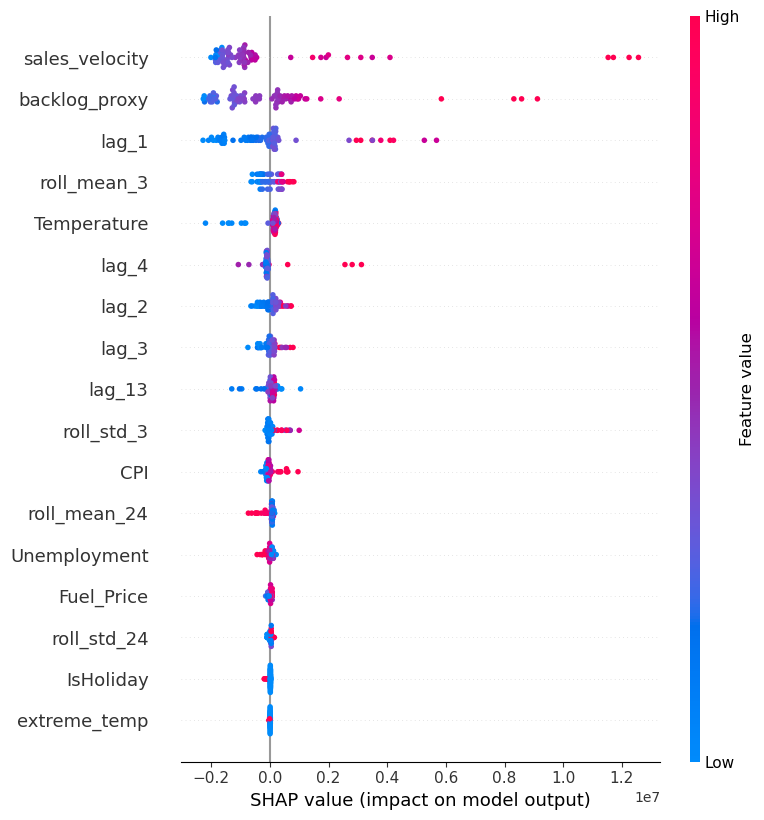

In [40]:
shap.summary_plot(shap_values, X_tmp)

plot (summary plot → behavior) shows:
this plot shows X-axis: SHAP value = impact on prediction
    Right → pushes prediction higher (more load)
    Left → pushes prediction lower (less load)

Color:
    🔴 Red = high feature value
    🔵 Blue = low feature value
    
Color → Position → Pattern


The model is driven by:

    1. Demand dynamics 
            sales_velocity
            backlog_proxy
    2. Recent history
            lag_1
    3. Minor contributors
            temperature
            rolling averages
    4. Negligible features
            CPI, unemployment, extreme_temp

The model is not just predicting demand 
    — it is capturing: how demand behaves 
            Speed of change (velocity)
            Deviation from expectation (backlog)



The SHAP summary plot shows that the model is primarily driven by demand dynamics, particularly sales velocity and backlog proxy, which capture rapid changes and deviations in demand. High values of these features consistently push predictions upward, indicating increased workload. Lag features also contribute significantly, reflecting the importance of recent demand patterns. In contrast, external economic indicators and extreme temperature have minimal influence, suggesting that short-term operational decisions are largely driven by internal demand signals

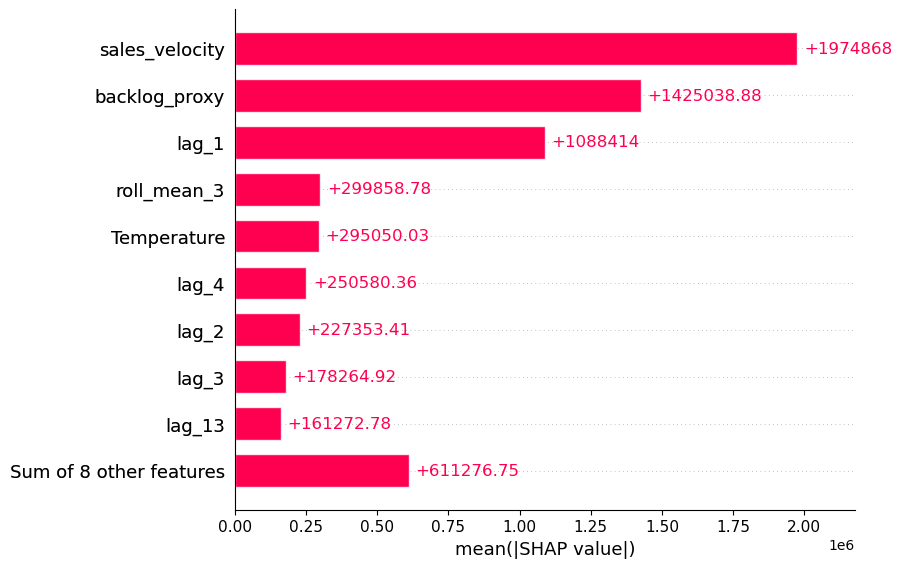

In [41]:
shap.plots.bar(shap_values)

SHAP bar plot shows X-axis = mean(|SHAP value|), how much each feature influences predictions on average- Higher = more important

The model is driven by:

    1. Demand dynamics (velocity + backlog) 
    2. Recent history (lags)
    3. Minor external influence

SHAP Model Interpretation
SHAP analysis indicates that the model is primarily driven by demand dynamics rather than external factors. Sales velocity emerges as the most influential feature, highlighting the importance of rapid changes in demand. The backlog proxy also plays a significant role, capturing deviations from recent trends and reflecting operational strain. Lag features further reinforce the importance of historical demand patterns, while external variables such as temperature and economic indicators contribute minimally.


The model is Demand-driven (excellent), Operationally meaningful (very strong), Not over-reliant on external noise (good)

In [42]:
y_tmp.head()

Date
2010-08-13    46464418.41
2010-08-20    47060952.92
2010-08-27    45909740.44
2010-09-03    47194257.61
2010-09-10    45634397.84
Freq: W-FRI, Name: y, dtype: float64

In [43]:
# to undestand what's going on, let's plot
# the values of y a few times before the start
# of the train set

y_train.head(10)

Date
2010-02-26    43968571.13
2010-03-05    46871470.30
2010-03-12    45925396.51
2010-03-19    44988974.64
2010-03-26    44133961.05
2010-04-02    50423831.26
2010-04-09    47365290.44
2010-04-16    45183667.08
2010-04-23    44734452.56
2010-04-30    43705126.71
Freq: W-FRI, Name: Weekly_Sales, dtype: float64

In [44]:
len(X_test)

43

In [45]:
len(y_test)

43

In [46]:
# Fix data types
df[features].dtypes

IsHoliday            bool
Temperature       float64
Fuel_Price        float64
CPI               float64
Unemployment      float64
sales_velocity    float64
backlog_proxy     float64
extreme_temp        int64
dtype: object

In [47]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

In [48]:
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

In [49]:
# Fix data types
df['IsHoliday'] = df['IsHoliday'].astype(int)

df[features] = df[features].apply(pd.to_numeric, errors='coerce')

# Handle missing values
# df = df.fillna(method='ffill')
# df = df.fillna(method='bfill')

df = df.ffill()
df = df.bfill()

# Ensure numeric
df[features] = df[features].astype(float)

# Define inputs
y = df['Weekly_Sales']
exog = df[features]

In [50]:
df = df.asfreq('W-FRI')
# After asfreq
df = df.sort_index()
# df = df.fillna(method='ffill')
# df = df.fillna(method='bfill')   # just in case first rows are NaN

df = df.ffill()
df = df.bfill()

# 6. Backtesting and Forecast Validation

Backtesting simulates how the forecasting model would perform over time on unseen future periods. This is stronger than a single train/test split because it better reflects real forecasting conditions.

In [51]:
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold

In [52]:
# Define how time series will be split during backtesting
cv = TimeSeriesFold(
    steps=1,
    initial_train_size=100,
    refit=True,
    fixed_train_size=False,
)

## Lightweight LASSO Comparison

LASSO is included as a simple linear benchmark. The goal is not to over-optimize LASSO, but to show that the final model choice was evaluated against a simpler alternative.

In [53]:
# run this code just to get rmse for lasso backtesting
from sklearn.linear_model import Lasso
# from skforecast.recursive import ForecasterRecursive
# from skforecast.model_selection import backtesting_forecaster

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso_pipeline = Pipeline([
    # ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=9, max_iter=300000, tol=0.1))
])

# Create forecaster
linear_forecaster = ForecasterRecursive(
    estimator=lasso_pipeline,            # the machine learning model
    lags=[1, 2, 3, 4, 13],         # the lag features to create
    window_features = rolling_features,

)

y_train = y_train.dropna()
# fit the forecaster
linear_forecaster.fit(y=y_train)

# Define how time series will be split during backtesting
cv_lasso = TimeSeriesFold(
    steps=1,
    initial_train_size=100,
    refit=True,
    fixed_train_size=False,
    verbose=True
)

df = df.dropna()

# Backtesting
metric_linear_lasso, predictions_linear_lasso = backtesting_forecaster(
    forecaster=linear_forecaster,
    y=df['Weekly_Sales'].asfreq('W-FRI'),   
    exog=df[features].asfreq('W-FRI'),
    cv=cv_lasso,
    metric=["mean_squared_error"],
    verbose=False,
    show_progress=True,
)

rmse_lasso = np.sqrt(metric_linear_lasso.iloc[0])
print("Lasso RMSE:", rmse_lasso)

print("-------------------------------------------------------------------------")

  0%|          | 0/40 [00:00<?, ?it/s]

Lasso RMSE: mean_squared_error    1.385610e+06
Name: 0, dtype: float64
-------------------------------------------------------------------------


In [54]:
# Linear forecaster backtesting
metric_linear, predictions_linear = backtesting_forecaster(
    forecaster=forecaster,
    y=df['Weekly_Sales'].asfreq('W-FRI'),
    exog=df[features].asfreq('W-FRI'),
    cv=cv,
    metric=["mean_squared_error"],
    verbose=  False,
    show_progress=True,
)

  0%|          | 0/40 [00:00<?, ?it/s]

In [55]:
# import numpy as np

mse_value = metric_linear.iloc[0]
rmse = np.sqrt(mse_value)

print("MSE for XGBoost:", metric_linear)
print("RMSE for XGBoost:", rmse)

MSE for XGBoost:    mean_squared_error
0        8.867589e+11
RMSE for XGBoost: mean_squared_error    941678.775731
Name: 0, dtype: float64


Model performance was evaluated using Mean Squared Error (MSE), with Root Mean Squared Error (RMSE) used for interpretability in business terms

In [56]:
df[features].asfreq('W-FRI')

,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
Date,,,,,,,,
2010-02-26,0.0,38.629563,2.685642,167.691019,8.561375,-0.089244,-0.075965,1.0
2010-03-05,0.0,42.373998,2.731816,167.727351,8.572689,0.066022,0.000172,0.0
2010-03-12,0.0,46.967143,2.774452,167.504162,8.580858,-0.020184,-0.007246,0.0
2010-03-19,0.0,49.481019,2.816063,167.478101,8.571996,-0.020390,-0.009895,0.0
2010-03-26,0.0,47.979325,2.823610,167.510338,8.575041,-0.019005,-0.029595,0.0
...,...,...,...,...,...,...,...,...
2012-09-28,0.0,68.151759,3.858245,175.919639,7.225855,-0.013970,-0.031586,0.0
2012-10-05,0.0,65.456811,3.848435,175.998254,6.942141,0.087613,0.057729,0.0
2012-10-12,0.0,57.687284,3.897425,176.123786,6.952682,-0.030234,0.015015,0.0


In [57]:
y = df['Weekly_Sales']
exog = df[features]

In [58]:
len(y_train)

97

In [59]:
exog

,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,sales_velocity,backlog_proxy,extreme_temp
Date,,,,,,,,
2010-02-26,0.0,38.629563,2.685642,167.691019,8.561375,-0.089244,-0.075965,1.0
2010-03-05,0.0,42.373998,2.731816,167.727351,8.572689,0.066022,0.000172,0.0
2010-03-12,0.0,46.967143,2.774452,167.504162,8.580858,-0.020184,-0.007246,0.0
2010-03-19,0.0,49.481019,2.816063,167.478101,8.571996,-0.020390,-0.009895,0.0
2010-03-26,0.0,47.979325,2.823610,167.510338,8.575041,-0.019005,-0.029595,0.0
...,...,...,...,...,...,...,...,...
2012-09-28,0.0,68.151759,3.858245,175.919639,7.225855,-0.013970,-0.031586,0.0
2012-10-05,0.0,65.456811,3.848435,175.998254,6.942141,0.087613,0.057729,0.0
2012-10-12,0.0,57.687284,3.897425,176.123786,6.952682,-0.030234,0.015015,0.0


In [60]:
len(df[features].asfreq('W-FRI'))

140

In [61]:
y_train = y_train.dropna()

In [62]:
len(y_train)

97

In [63]:
print(type(forecaster))
print(type(linear_forecaster))

<class 'skforecast.recursive._forecaster_recursive.ForecasterRecursive'>
<class 'skforecast.recursive._forecaster_recursive.ForecasterRecursive'>


In [64]:
print(id(forecaster))
print(id(linear_forecaster))

2040862223264
2040865155792


## Seasonal Naive Baseline Comparison

A seasonal naive baseline is used as a practical comparison point. This helps answer: does the machine learning model improve over a simple repeat-last-season approach?

In [65]:
df_baseline = df.copy()

df_baseline['seasonal_naive'] = df['Weekly_Sales'].shift(52)

# Align with backtesting period
df_baseline = df_baseline.loc[predictions_linear.index]

from sklearn.metrics import mean_squared_error
import numpy as np

mse_naive = mean_squared_error(
    df_baseline['Weekly_Sales'],
    df_baseline['seasonal_naive']
)

rmse_seasonal = np.sqrt(mse_naive)

print("Seasonal RMSE:", rmse_seasonal)

Seasonal RMSE: 2006103.8561220695


In [66]:
rmse_diff = rmse_seasonal - rmse
rmse_pct = (rmse_diff / rmse_seasonal) * 100

print("XGBoost RMSE:", rmse)
print("Seasonal RMSE:", rmse_seasonal)
print("Improvement xgboost from seasonal:", rmse_diff)
print("Improvement xgboost from Seasonal %:", rmse_pct)

XGBoost RMSE: mean_squared_error    941678.775731
Name: 0, dtype: float64
Seasonal RMSE: 2006103.8561220695
Improvement xgboost from seasonal: mean_squared_error    1.064425e+06
Name: 0, dtype: float64
Improvement xgboost from Seasonal %: mean_squared_error    53.059321
Name: 0, dtype: float64


The XGBoost model reduced forecasting error by approximately 53% compared to a seasonal naive baseline, demonstrating its ability to capture temporal dynamics and external demand drivers beyond simple yearly seasonality

In [67]:
rmse_diff_lasso = rmse_seasonal - rmse_lasso
rmse_pct_lasso = (rmse_diff_lasso / rmse_seasonal) * 100
print("Lasso RMSE:", rmse_lasso)
print("Improvement lasso from seasonal:", rmse_diff_lasso)
print("Improvement lasso from Seasonal %:", rmse_pct_lasso)

Lasso RMSE: mean_squared_error    1.385610e+06
Name: 0, dtype: float64
Improvement lasso from seasonal: mean_squared_error    620494.213401
Name: 0, dtype: float64
Improvement lasso from Seasonal %: mean_squared_error    30.930314
Name: 0, dtype: float64


The lasso model reduced forecasting error by approximately 31% compared to a seasonal naive baseline

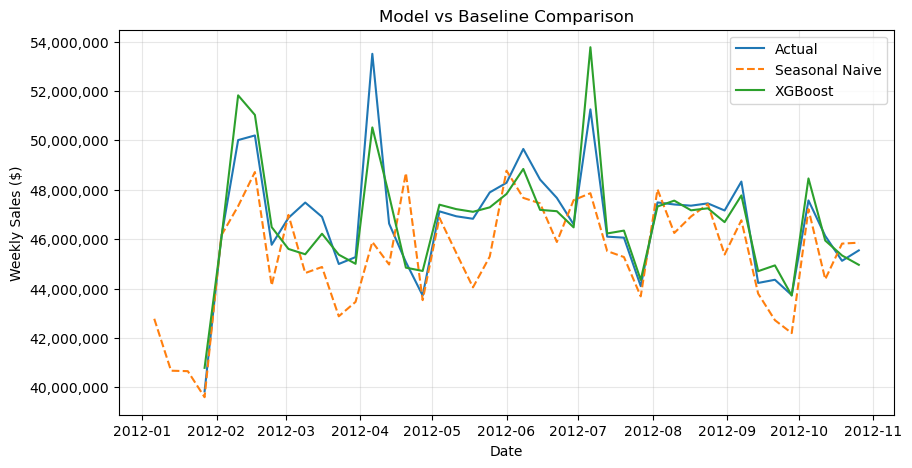

In [68]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.plot(df_baseline.index, df_baseline['Weekly_Sales'], label='Actual')

seasonal_naive_full = df['Weekly_Sales'].shift(52)
seasonal_naive_pred = seasonal_naive_full.loc[y_test.index]
ax.plot(
    seasonal_naive_pred.index,
    seasonal_naive_pred,
    label='Seasonal Naive',
    linestyle='--'
)


plt.plot(predictions_linear.index, predictions_linear['pred'], label='XGBoost')

plt.legend()
plt.title("Model vs Baseline Comparison")

ax.set_title("Model vs Baseline Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Sales ($)")

ax.grid(alpha=0.3)

plt.show()

Your chart already shows something very good:

- XGBoost (green) tracks actual closely 
- Seasonal naive is weaker 

The model captures both seasonal and short-term demand fluctuations more accurately than a seasonal naive baseline

Backtesting was used to simulate real-world forecasting conditions by iteratively training and predicting across time, ensuring the model’s performance reflects practical deployment scenarios.

In [69]:
# save chart resuts to csv
plot_df = pd.DataFrame({
    'Date': predictions_linear.index,
    'Actual': df_baseline.loc[predictions_linear.index, 'Weekly_Sales'],
    'Seasonal_Naive': seasonal_naive_pred.loc[predictions_linear.index],
    'XGBoost': predictions_linear['pred']
})

plot_df = plot_df.dropna()

plot_df.to_csv('backtesting model_vs_baseline.csv', index=False)


# 7. VET/VTO Workforce Decision Logic

Forecast outputs are converted into operational staffing recommendations: VET for high demand, VTO for low demand, and Normal for middle-range demand.

In [70]:
df_results = predictions_linear.copy()

# Add actual values
df_results['actual'] = df['Weekly_Sales'].loc[predictions_linear.index]

In [71]:
# Add error
df_results['error'] = df_results['actual'] - df_results['pred']
df_results['abs_error'] = df_results['error'].abs()

In [72]:
# Add VET / VTO decisions
high = df_results['pred'].quantile(0.75)
low  = df_results['pred'].quantile(0.25)

df_results['decision'] = 'Normal'
df_results.loc[df_results['pred'] > high, 'decision'] = 'VET'
df_results.loc[df_results['pred'] < low,  'decision'] = 'VTO'

In [73]:
# Add actual decisions (ground truth)
df_results['actual_decision'] = 'Normal'
df_results.loc[df_results['actual'] > high, 'actual_decision'] = 'VET'
df_results.loc[df_results['actual'] < low,  'actual_decision'] = 'VTO'

In [74]:
# Evaluate decision accuracy
accuracy = (df_results['decision'] == df_results['actual_decision']).mean()
print("Decision Accuracy:", accuracy)

Decision Accuracy: 0.75


In [75]:
df_results.head()

,fold,pred,actual,error,abs_error,decision,actual_decision
2012-01-27,0,40788084.0,39834974.67,-953109.33,953109.33,VTO,VTO
2012-02-03,1,46012100.0,46085608.09,73508.09,73508.09,Normal,Normal
2012-02-10,2,51820868.0,50009407.92,-1811460.08,1811460.08,VET,VET
2012-02-17,3,51027920.0,50197056.96,-830863.04,830863.04,VET,VET
2012-02-24,4,46486864.0,45771506.57,-715357.43,715357.43,Normal,Normal


## Class-by-Class Interpretation

In [76]:
df_results['decision'].value_counts()

decision
Normal    20
VTO       10
VET       10
Name: count, dtype: int64

In [77]:
pd.crosstab(
    df_results['actual_decision'],
    df_results['decision']
)

decision,Normal,VET,VTO
actual_decision,,,
Normal,13,2,1
VET,6,8,0
VTO,1,0,9


The model is not biased toward one decision
It produces a balanced distribution
The model is making a realistic mix of decisions — not over-triggering VET or VTO.

Strong diagonal = good model Correct predictions are on the diagonal:
    Normal → Normal = 13
    VET → VET = 8
    VTO → VTO = 9

Extreme demand detection is excellent - VET: 8 correct out of 14 total ≈ 57% recall
    0 predicted as VTO        - This is critical: The model never confuses high demand with low demand

VTO: 
    9 correct out of 10 = 90% accuracy - Very strong

The model behaves Excellent at detecting extremes (VET/VTO),  No dangerous mistakes (no VET ↔ VTO confusion), Minor errors only in transition zones


In [78]:
print("Mistake Type   | Count")
print("------------------------")
print("VET → VTO      |", ((df_results['actual_decision']=='VET') & (df_results['decision']=='VTO')).sum())
print("VTO → VET      |", ((df_results['actual_decision']=='VTO') & (df_results['decision']=='VET')).sum())

Mistake Type   | Count
------------------------
VET → VTO      | 0
VTO → VET      | 0


The model avoids critical errors such as confusing high-demand (VET) with low-demand (VTO), which is essential for operational reliability.

Refitting during backtesting mimics how the model would be updated in production, so the validation results represent real-world performance rather than a one-time estimate

I am refitting all the time, so I am getting real validation and real capability. Backtesting evaluates whether the model can accurately predict weekly demand over time, and whether those predictions can be reliably used to make correct VET/VTO decisions.

# 8. Cost Savings Analysis

The cost model estimates the financial impact of staffing decision errors. The objective is not to reproduce exact enterprise payroll accounting, but to compare relative staffing costs between the XGBoost model and the seasonal naive baseline.

## Costs

Sales (dollars) → Labor demand (hours or workers)
More sales → more workload → more labor needed
The data has:Weekly_Sales ($) but we want Labor decisions (workers / hours). 

There is no direct mapping in the dataset. 
Assume store doing $1,000,000 in weekly sales might roughly correspond to 1,000 labor-hours of workload

    sales_to_labor = 1000 / 1_000_000
    sales_to_labor = 0.001             interpret as every $1,000 of sales ≈ 1 labor-hour

The pipeline now becomes: Sales error → Labor mismatch → Cost

Because the Walmart dataset does not include staffing data, weekly sales were treated as a proxy for labor demand. A scaling factor of 0.001 was used, meaning that each $1,000 of sales corresponds approximately to 1 labor-hour. This assumption was used to estimate relative labor cost impact rather than exact payroll cost

In [79]:
upper_threshold = y.quantile(0.75)
lower_threshold = y.quantile(0.25)

In [80]:
def classify(value):
    if value > upper_threshold:
        return "VET"
    elif value < lower_threshold:
        return "VTO"
    else:
        return "Normal"

In [81]:
# Define wages assumptions
hourly_wage = 20
overtime_wage = 30

# scaling factor  $1,000 sales ≈ 1 labor-hour. This is an approximation for relative comparison, not exact payroll estimation.
sales_to_labor = 0.001

We are calculating how expensive that mistake is. Real-world consequence
Workers idle and Paid $30/hour unnecessarily

In [82]:
print("Mistake                        |   Cost")
print("------------------------------------------")
print("Understaffing  (miss VET)      |   High ($30/hr)")
print("Overstaffing   (miss VTO)      |   Lower ($20/hr)")


Mistake                        |   Cost
------------------------------------------
Understaffing  (miss VET)      |   High ($30/hr)
Overstaffing   (miss VTO)      |   Lower ($20/hr)


.clip(lower=0) ensures only  real mistakes generate cost. 

Prediction error → Decision error → Financial impact

In [83]:
df_results['decision'].unique()
df_results['actual_decision'].unique()

array(['VTO', 'Normal', 'VET'], dtype=object)

In [84]:
df_results.head()

,fold,pred,actual,error,abs_error,decision,actual_decision
2012-01-27,0,40788084.0,39834974.67,-953109.33,953109.33,VTO,VTO
2012-02-03,1,46012100.0,46085608.09,73508.09,73508.09,Normal,Normal
2012-02-10,2,51820868.0,50009407.92,-1811460.08,1811460.08,VET,VET
2012-02-17,3,51027920.0,50197056.96,-830863.04,830863.04,VET,VET
2012-02-24,4,46486864.0,45771506.57,-715357.43,715357.43,Normal,Normal


In [85]:
def calculate_staffing_cost(
    df,
    pred_col,
    decision_col,
    cost_col_name,
    sales_to_labor,
    overtime_wage,
    hourly_wage
):
    df[cost_col_name] = 0.0

    # UNDERSTAFFING
    mask_under = (
        (df['actual_decision'] == 'VET') &
        (df[decision_col] != 'VET')
    )

    df.loc[mask_under, cost_col_name] = (
        (df['actual'] - df[pred_col]).clip(lower=0)
        * sales_to_labor
        * overtime_wage
    )

    # OVERSTAFFING
    mask_over = (
        (df['actual_decision'] == 'VTO') &
        (df[decision_col] != 'VTO')
    )

    df.loc[mask_over, cost_col_name] = (
        (df[pred_col] - df['actual']).clip(lower=0)
        * sales_to_labor
        * hourly_wage
    )

    return df, mask_under, mask_over

In [86]:
df_results, model_mask_under, model_mask_over = calculate_staffing_cost(
    df_results,
    pred_col='pred',
    decision_col='decision',
    cost_col_name='model_cost',
    sales_to_labor=sales_to_labor,
    overtime_wage=overtime_wage,
    hourly_wage=hourly_wage
)

In [87]:
# df_results['model cost'] = 0.0

# # UNDERSTAFFING (missed VET → expensive)
# mask_under = (
#     (df_results['actual_decision'] == 'VET') & 
#     (df_results['decision'] != 'VET')
# )

# df_results.loc[mask_under, 'model cost'] = (
#     (df_results['actual'] - df_results['pred']).clip(lower=0)
#     * sales_to_labor
#     * overtime_wage
# )

# # OVERSTAFFING (missed VTO → waste)
# mask_over = (
#     (df_results['actual_decision'] == 'VTO') & 
#     (df_results['decision'] != 'VTO')
# )

# df_results.loc[mask_over, 'model cost'] = (
#     (df_results['pred'] - df_results['actual']).clip(lower=0)
#     * sales_to_labor
#     * hourly_wage
# )

In [88]:
#Naive baseline (shift)
#get full seasonl dataset
df_full = df.copy()
df_full['naive_pred'] = df_full['Weekly_Sales'].shift(52)
#merge
df_results['naive_pred'] = df_full.loc[df_results.index, 'naive_pred']

df_results['naive_decision'] = df_results['naive_pred'].apply(classify)


In [89]:
df_results, naive_mask_under, naive_mask_over = calculate_staffing_cost(
    df_results,
    pred_col='naive_pred',
    decision_col='naive_decision',
    cost_col_name='naive_cost',
    sales_to_labor=sales_to_labor,
    overtime_wage=overtime_wage,
    hourly_wage=hourly_wage
)

In [90]:
 # df_results.head(100)

In [91]:
# # Cost calculation (MODEL)

# df_results['naive_cost'] = 0.0

# # UNDERSTAFFING (baseline)
# mask_under_naive = (
#     (df_results['actual_decision'] == 'VET') & 
#     (df_results['naive_decision'] != 'VET')
# )

# df_results.loc[mask_under_naive, 'naive_cost'] = (
#     (df_results['actual'] - df_results['naive_pred']).clip(lower=0)
#     * sales_to_labor
#     * overtime_wage
# )

# # OVERSTAFFING (baseline)
# mask_over_naive = (
#     (df_results['actual_decision'] == 'VTO') & 
#     (df_results['naive_decision'] != 'VTO')
# )

# df_results.loc[mask_over_naive, 'naive_cost'] = (
#     (df_results['naive_pred'] - df_results['actual']).clip(lower=0)
#     * sales_to_labor
#     * hourly_wage
# )

In [92]:
df_results.head(100)

,fold,pred,actual,error,abs_error,decision,actual_decision,model_cost,naive_pred,naive_decision,naive_cost
2012-01-27,0,40788084.0,39834974.67,-953109.33,953109.33,VTO,VTO,0.0000,39599852.99,VTO,0.0000
2012-02-03,1,46012100.0,46085608.09,73508.09,73508.09,Normal,Normal,0.0000,46153111.12,Normal,0.0000
2012-02-10,2,51820868.0,50009407.92,-1811460.08,1811460.08,VET,VET,0.0000,47336192.79,Normal,80196.4539
2012-02-17,3,51027920.0,50197056.96,-830863.04,830863.04,VET,VET,0.0000,48716164.12,VET,0.0000
2012-02-24,4,46486864.0,45771506.57,-715357.43,715357.43,Normal,Normal,0.0000,44125859.84,VTO,0.0000
2012-03-02,5,45602180.0,46861034.97,1258854.97,1258854.97,Normal,Normal,0.0000,46980603.74,Normal,0.0000
2012-03-09,6,45387080.0,47480454.11,2093374.11,2093374.11,Normal,VET,62801.2233,44627319.40,VTO,85594.0413
2012-03-16,7,46218440.0,46901504.94,683064.94,683064.94,Normal,Normal,0.0000,44872325.97,Normal,0.0000
2012-03-23,8,45370716.0,44993794.45,-376921.55,376921.55,Normal,VTO,7538.4310,42876199.18,VTO,0.0000
2012-03-30,9,45001192.0,45272862.02,271670.02,271670.02,VTO,VTO,0.0000,43458991.19,VTO,0.0000


In [93]:
baseline_cost = df_results['naive_cost'].sum()
model_cost = df_results['model_cost'].sum()

print("Naive Season Cost:", baseline_cost)
print("XGBoost Model Cost:", model_cost)
print("Model Cost Savings against seasonalCost:", baseline_cost - model_cost)

Naive Season Cost: 699247.1744000004
XGBoost Model Cost: 152391.87850000017
Model Cost Savings against seasonalCost: 546855.2959000003


In [94]:
print("Understaffing cases using the Model:", model_mask_under.sum())
print("Overstaffing cases using the Model:", model_mask_over.sum())

Understaffing cases using the Model: 6
Overstaffing cases using the Model: 1


In [95]:
print("Understaffing cases using Seasonal Naive baseline:", naive_mask_under.sum())
print("Overstaffing cases using Seasonal Naive baseline:", naive_mask_over.sum())

Understaffing cases using Seasonal Naive baseline: 9
Overstaffing cases using Seasonal Naive baseline: 2


In [96]:
percent_savings = (baseline_cost - model_cost) / baseline_cost * 100
print("Percentage Cost Reduction:", percent_savings)

Percentage Cost Reduction: 78.20629327093638


Compared to a seasonal naïve baseline, the XGBoost model reduces operational cost by 78.2% while significantly minimizing both understaffing and overstaffing decisions.

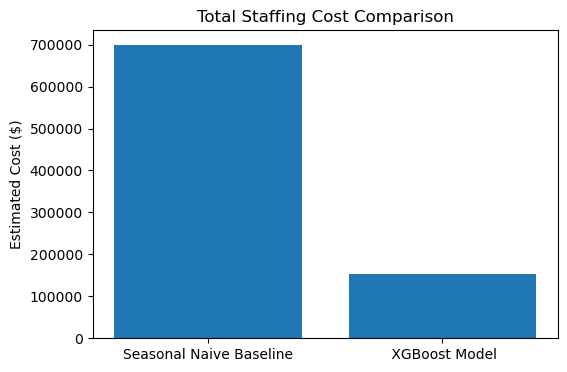

In [97]:
import matplotlib.pyplot as plt

labels = ['Seasonal Naive Baseline', ' XGBoost Model']
values = [baseline_cost, model_cost]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title('Total Staffing Cost Comparison')
plt.ylabel('Estimated Cost ($)')

plt.show()

This chart shows the total staffing cost comparison between the seasonal naïve baseline and the XGBoost model. The baseline approach results in significantly higher costs due to inefficient staffing decisions. In contrast, the XGBoost model more accurately predicts demand, enabling better use of VET and VTO. This reduces both understaffing and overstaffing, leading to an overall cost reduction of approximately –78%..

The model reduces misclassification of high- and low-demand periods, leading to more efficient labor allocation and lower operational costs.

In [98]:
# save csv results
import pandas as pd

cost_df = pd.DataFrame({
    'Model': ['Seasonal Naive', 'XGBoost'],
    'Total Cost': [baseline_cost, model_cost]
})

cost_df.to_csv('Naive vs XGBoost cost_comparison.csv', index=False)

# 9. Cumulative Savings and Final Business Impact

Cumulative savings show how improved forecasting can reduce staffing inefficiency over time compared with a seasonal naive baseline.

## Cumulative Savings Graph

In [99]:
# weekly savings
df_results['savings'] = df_results['naive_cost'] - df_results['model_cost']

In [100]:
# weekly savings
df_results['cumulative_savings'] = df_results['savings'].cumsum()

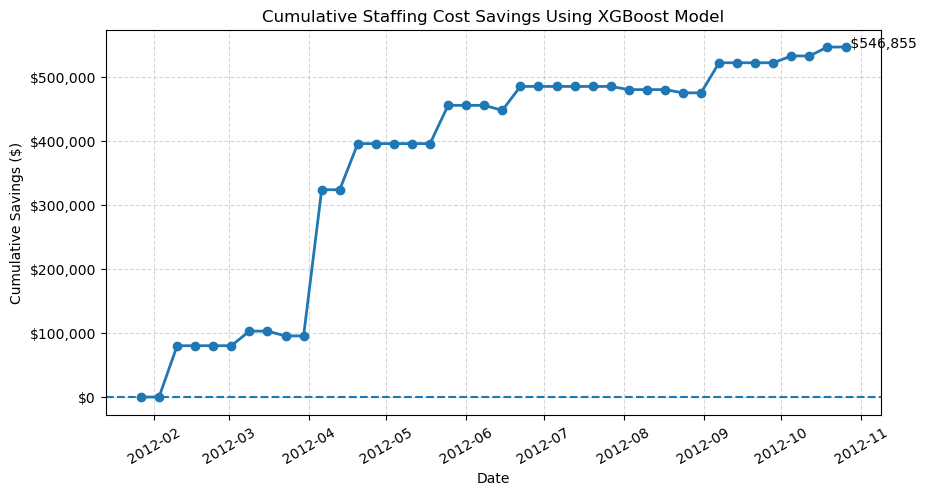

In [101]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 5))

plt.plot(
    df_results.index,
    df_results['cumulative_savings'],
    marker='o',
    linewidth=2
)

plt.title('Cumulative Staffing Cost Savings Using XGBoost Model')
plt.xlabel('Date')
plt.ylabel('Cumulative Savings ($)')

# Format currency
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Zero line
plt.axhline(0, linestyle='--')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Rotate dates
plt.xticks(rotation=30)

# Final value label
final_value = df_results['cumulative_savings'].iloc[-1]
plt.text(df_results.index[-1], final_value,
         f' ${final_value:,.0f}', fontsize=10, ha='left')

plt.show()

This chart shows cumulative staffing cost savings over time when using the XGBoost model instead of the seasonal naïve baseline. The steady upward trend indicates consistent cost savings week over week, reaching approximately $550,000 by the end of the period.

In [102]:
# Create export dataframe with Date + Cumulative Savings
df_export = df_results[['savings', 'cumulative_savings']].copy()
df_export = df_export.reset_index()
df_export.columns = ['Date', 'Weekly_Savings', 'Cumulative_Savings']
df_export.to_csv('savings_full.csv', index=False)

# 10. Model Export for Application Deployment

This final cell saves the trained model so it can be used by the Streamlit/Flask forecasting application. Run this after confirming the final model object name in the notebook.

In [103]:
# Save trained model for deployment
# Uncomment and adjust model variable name if needed.

import os
import joblib

os.makedirs('models', exist_ok=True)


# If your final trained model variable is named `model`, this will save it:
joblib.dump({
    "forecaster": forecaster,
    "vet_threshold": upper_threshold,
    "vto_threshold": lower_threshold,
}, "warehouse_system.pkl")


# joblib.dump(model, 'models/xgboost_model.pkl')

print('Model saved to models/warehouse_system.pkl')

Model saved to models/warehouse_system.pkl


# Final Summary

This notebook demonstrates an end-to-end workforce forecasting workflow:

- Walmart sales data is used as a proxy for warehouse labor demand.
- XGBoost recursive forecasting predicts future operational demand.
- Backtesting validates forecasting performance over time.
- SHAP explains key model drivers.
- Forecast outputs are converted into VET/VTO staffing decisions.
- Cost savings are estimated against a seasonal naive baseline.

This project is focused on operational forecasting, workforce planning, and supply chain analytics.